In \[1\]:

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.svm import SVC

In \[3\]:

    df = pd.read_csv("C:\\WA_Fn-UseC_-Telco-Customer-Churn (2).csv")

In \[4\]:

    print(df.head())
    print(df.shape)
    print(df.info())
    print(df.describe())

       customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
    0  7590-VHVEG  Female              0     Yes         No       1           No   
    1  5575-GNVDE    Male              0      No         No      34          Yes   
    2  3668-QPYBK    Male              0      No         No       2          Yes   
    3  7795-CFOCW    Male              0      No         No      45           No   
    4  9237-HQITU  Female              0      No         No       2          Yes   

          MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
    0  No phone service             DSL             No  ...               No   
    1                No             DSL            Yes  ...              Yes   
    2                No             DSL            Yes  ...               No   
    3  No phone service             DSL            Yes  ...              Yes   
    4                No     Fiber optic             No  ...               No   

      TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
    0          No          No              No  Month-to-month              Yes   
    1          No          No              No        One year               No   
    2          No          No              No  Month-to-month              Yes   
    3         Yes          No              No        One year               No   
    4          No          No              No  Month-to-month              Yes   

                   PaymentMethod MonthlyCharges  TotalCharges Churn  
    0           Electronic check          29.85         29.85    No  
    1               Mailed check          56.95        1889.5    No  
    2               Mailed check          53.85        108.15   Yes  
    3  Bank transfer (automatic)          42.30       1840.75    No  
    4           Electronic check          70.70        151.65   Yes  

    [5 rows x 21 columns]
    (7043, 21)
    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 7043 entries, 0 to 7042
    Data columns (total 21 columns):
     #   Column            Non-Null Count  Dtype  
    ---  ------            --------------  -----  
     0   customerID        7043 non-null   object 
     1   gender            7043 non-null   object 
     2   SeniorCitizen     7043 non-null   int64  
     3   Partner           7043 non-null   object 
     4   Dependents        7043 non-null   object 
     5   tenure            7043 non-null   int64  
     6   PhoneService      7043 non-null   object 
     7   MultipleLines     7043 non-null   object 
     8   InternetService   7043 non-null   object 
     9   OnlineSecurity    7043 non-null   object 
     10  OnlineBackup      7043 non-null   object 
     11  DeviceProtection  7043 non-null   object 
     12  TechSupport       7043 non-null   object 
     13  StreamingTV       7043 non-null   object 
     14  StreamingMovies   7043 non-null   object 
     15  Contract          7043 non-null   object 
     16  PaperlessBilling  7043 non-null   object 
     17  PaymentMethod     7043 non-null   object 
     18  MonthlyCharges    7043 non-null   float64
     19  TotalCharges      7043 non-null   object 
     20  Churn             7043 non-null   object 
    dtypes: float64(1), int64(2), object(18)
    memory usage: 1.1+ MB
    None
           SeniorCitizen       tenure  MonthlyCharges
    count    7043.000000  7043.000000     7043.000000
    mean        0.162147    32.371149       64.761692
    std         0.368612    24.559481       30.090047
    min         0.000000     0.000000       18.250000
    25%         0.000000     9.000000       35.500000
    50%         0.000000    29.000000       70.350000
    75%         0.000000    55.000000       89.850000
    max         1.000000    72.000000      118.750000

In \[5\]:

    print(df.isnull().sum())

    customerID          0
    gender              0
    SeniorCitizen       0
    Partner             0
    Dependents          0
    tenure              0
    PhoneService        0
    MultipleLines       0
    InternetService     0
    OnlineSecurity      0
    OnlineBackup        0
    DeviceProtection    0
    TechSupport         0
    StreamingTV         0
    StreamingMovies     0
    Contract            0
    PaperlessBilling    0
    PaymentMethod       0
    MonthlyCharges      0
    TotalCharges        0
    Churn               0
    dtype: int64

In \[6\]:

    # Churn Distribution
    sns.countplot(x='Churn', data=df)
    plt.show()

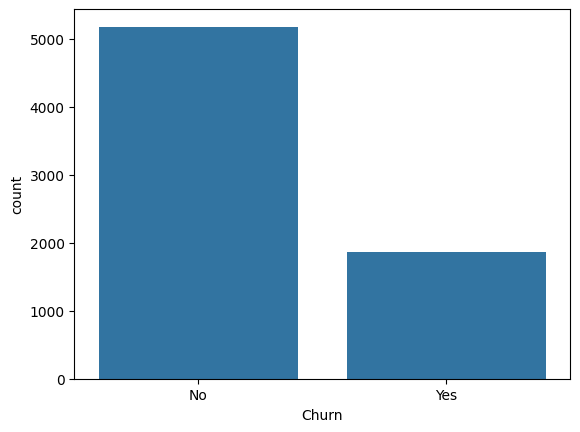

In \[7\]:

    # Tenure vs Churn
    sns.boxplot(x="Churn", y="tenure", data=df)
    plt.show()

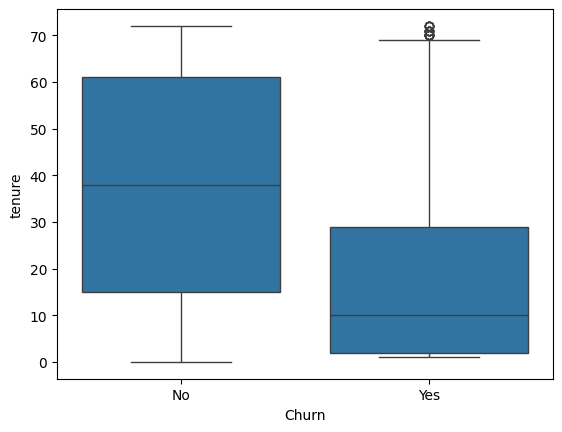

In \[8\]:

    sns.histplot(df["MonthlyCharges"], kde=True)
    plt.show()

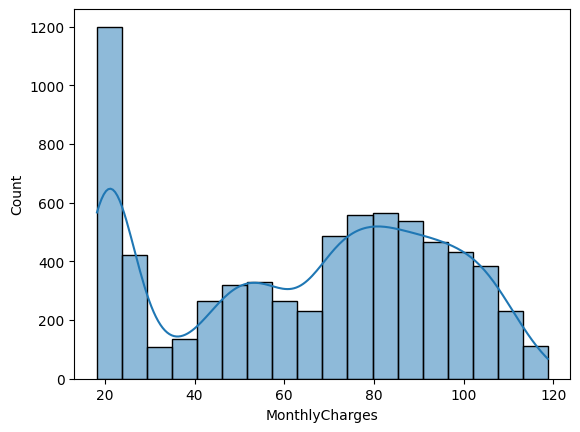

In \[9\]:

    # Remove CustomerID column
    df.drop("customerID", axis=1, inplace=True)

In \[10\]:

    # Convert TotalCharges to numeric
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In \[13\]:

    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In \[14\]:

    le = LabelEncoder()

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = le.fit_transform(df[col])

In \[15\]:

    X = df.drop("Churn", axis=1)
    y = df["Churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

In \[16\]:

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)
    print("Logistic Accuracy:", accuracy_score(y_test, pred_lr))

    Logistic Accuracy: 0.8168914123491838

    C:\Users\adity\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
    STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

    Increase the number of iterations to improve the convergence (max_iter=1000).
    You might also want to scale the data as shown in:
        https://scikit-learn.org/stable/modules/preprocessing.html
    Please also refer to the documentation for alternative solver options:
        https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
      n_iter_i = _check_optimize_result(

In \[17\]:

    # KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train, y_train)
    pred_knn = knn.predict(X_test)
    print("KNN Accuracy:", accuracy_score(y_test, pred_knn))

    KNN Accuracy: 0.7764371894960965

In \[18\]:

    # Decision Tree
    dt = DecisionTreeClassifier()
    dt.fit(X_train, y_train)
    pred_dt = dt.predict(X_test)
    print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

    Decision Tree Accuracy: 0.7281760113555713

In \[19\]:

    # Random Forest
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

    Random Forest Accuracy: 0.794180269694819

In \[20\]:

    # Support Vector Machine
    svm = SVC()
    svm.fit(X_train, y_train)
    pred_svm = svm.predict(X_test)
    print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

    SVM Accuracy: 0.7352732434350603

In \[21\]:

    # Gradient Boosting
    gb = GradientBoostingClassifier()
    gb.fit(X_train, y_train)
    pred_gb = gb.predict(X_test)
    print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred_gb))

    Gradient Boosting Accuracy: 0.8055358410220014

In \[22\]:

    results = pd.DataFrame({
        "Model": ["Logistic", "KNN", "Decision Tree", "Random Forest", "SVM", "Gradient Boosting"],
        "Accuracy": [
            accuracy_score(y_test, pred_lr),
            accuracy_score(y_test, pred_knn),
            accuracy_score(y_test, pred_dt),
            accuracy_score(y_test, pred_rf),
            accuracy_score(y_test, pred_svm),
            accuracy_score(y_test, pred_gb)
        ]
    })

    print(results)

                   Model  Accuracy
    0           Logistic  0.816891
    1                KNN  0.776437
    2      Decision Tree  0.728176
    3      Random Forest  0.794180
    4                SVM  0.735273
    5  Gradient Boosting  0.805536

In \[23\]:

    # ==============================
    cm = confusion_matrix(y_test, pred_rf)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

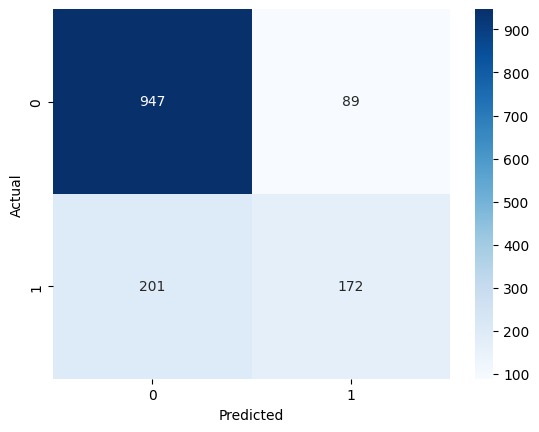

In \[24\]:

    # CLASSIFICATION REPORT
    # ==============================
    print(classification_report(y_test, pred_rf))

                  precision    recall  f1-score   support

               0       0.82      0.91      0.87      1036
               1       0.66      0.46      0.54       373

        accuracy                           0.79      1409
       macro avg       0.74      0.69      0.70      1409
    weighted avg       0.78      0.79      0.78      1409

In \[ \]: